# Caso Aplicativo — Restauración digital de documentos históricos

**Curso:** Procesamiento de Imágenes   
**Modalidad:** Grupal  
**Entregable:** este mismo notebook completado

---

## El escenario

Tu grupo acaba de ser contratado por el Archivo Nacional para digitalizar una colección de manuscritos del siglo XIX. Los documentos están en mal estado: manchas, desvanecimiento de la tinta, sombras del escáner, papel envejecido y, en algunos casos, ruido de un escaneo de baja calidad.

El trabajo es construir el pipeline de software que convierte esos escaneos en documentos legibles, listos para OCR. Esto es exactamente lo que hacen empresas como Ancestry, Google Books, FamilySearch y los proyectos de digitalización de bibliotecas nacionales. Las técnicas necesarias están todas en el Cap. 3, con apoyo de los Caps. 1 y 2.

## Lo que se integra de cada capítulo

| Capítulo | Conceptos que vas a usar |
|---|---|
| Cap. 1 — Representación | Cargar imagen, leer dtype/shape/rango, escala de grises vs color |
| Cap. 2 — Operaciones básicas | Indexación matricial, álgebra elemento a elemento, vecindades, convolución |
| Cap. 3 — Realce espacial | Transformaciones de intensidad, histogramas/ecualización, filtros de suavizado y afilado, métricas |

## Cómo está organizado este notebook

El notebook está dividido en seis partes, una por día más el cierre. Cada parte tiene:

- **Indicaciones**: qué tienes que hacer.
- **Preguntas**: para responder en celdas markdown.
- **Código a completar**: celdas con `TODO` que debes llenar.

**Importante sobre cómo funciona este notebook:** cada función a completar viene con una implementación *placeholder* que devuelve un valor válido pero incorrecto (típicamente, la imagen sin tocar). Esto permite que el notebook **corra end-to-end desde el inicio**, aunque los resultados serán malos. A medida que completes los TODOs, los números van a mejorar. Cada función trae también un test al final que te avisa si tu implementación sigue siendo un placeholder.

No borres las celdas con preguntas: responde **debajo** de cada una, en la celda markdown que ya está preparada con el texto _(tu respuesta)_.

## Rúbrica resumida

| Criterio | Peso |
|---|---|
| Completitud y corrección del código (todos los TODO resueltos) | 30% |
| Calidad de las respuestas a las preguntas | 25% |
| Justificación técnica (por qué esta técnica y no otra) | 20% |
| Mejora medida en las 6 imágenes | 15% |
| Presentación final (notebook limpio, figuras claras) | 10% |

**Penalizaciones:** entrega tarde −10 puntos por día. Notebook que no corre end-to-end −15. Plagio entre grupos: cero, sin segunda oportunidad.

---

## Parte 0 — Instalación de librerías

Si es la primera vez que corres este notebook, ejecuta esta celda para instalar las librerías necesarias. Si ya las tienes, `pip` te dirá *"already satisfied"* y seguirá adelante. **Después de instalar, reinicia el kernel** (Kernel → Restart) y corre desde la siguiente celda.

In [ ]:
# Solo se necesita ejecutar una vez. Las cuatro librerías son las únicas externas que usa el notebook.
%pip install numpy matplotlib scikit-image scipy

## Parte 1 — Configuración inicial

Esta celda carga las librerías y define dos funciones de ayuda que vas a usar muchas veces (`comparar` y `metricas`). Ejecútala después de instalar y reiniciar.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, exposure
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn
from scipy import ndimage as ndi

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['image.cmap'] = 'gray'

def comparar(imgs, titulos, figsize=None, cmap='gray'):
    """Muestra varias imágenes lado a lado."""
    n = len(imgs)
    fig, axes = plt.subplots(1, n, figsize=figsize or (4*n, 4))
    if n == 1: axes = [axes]
    for ax, img, t in zip(axes, imgs, titulos):
        ax.imshow(img, cmap=cmap, vmin=0, vmax=255 if img.dtype==np.uint8 else None)
        ax.set_title(t); ax.axis('off')
    plt.tight_layout(); plt.show()

def metricas(limpia, restaurada):
    """Calcula PSNR y SSIM entre la imagen limpia (referencia) y la restaurada."""
    return psnr_fn(limpia, restaurada), ssim_fn(limpia, restaurada)

print('Imports OK')

Imports OK


## Parte 2 — Generación del dataset (no modificar)

Para que puedas medir objetivamente cuánto mejora tu restauración, necesitamos imágenes degradadas a propósito a partir de una imagen limpia de referencia. Esto te da un *ground truth*. En la realidad solo tendrías la versión dañada, pero para aprender a medir, simulamos el daño.

No modifiques esta celda. Solo ejecútala.

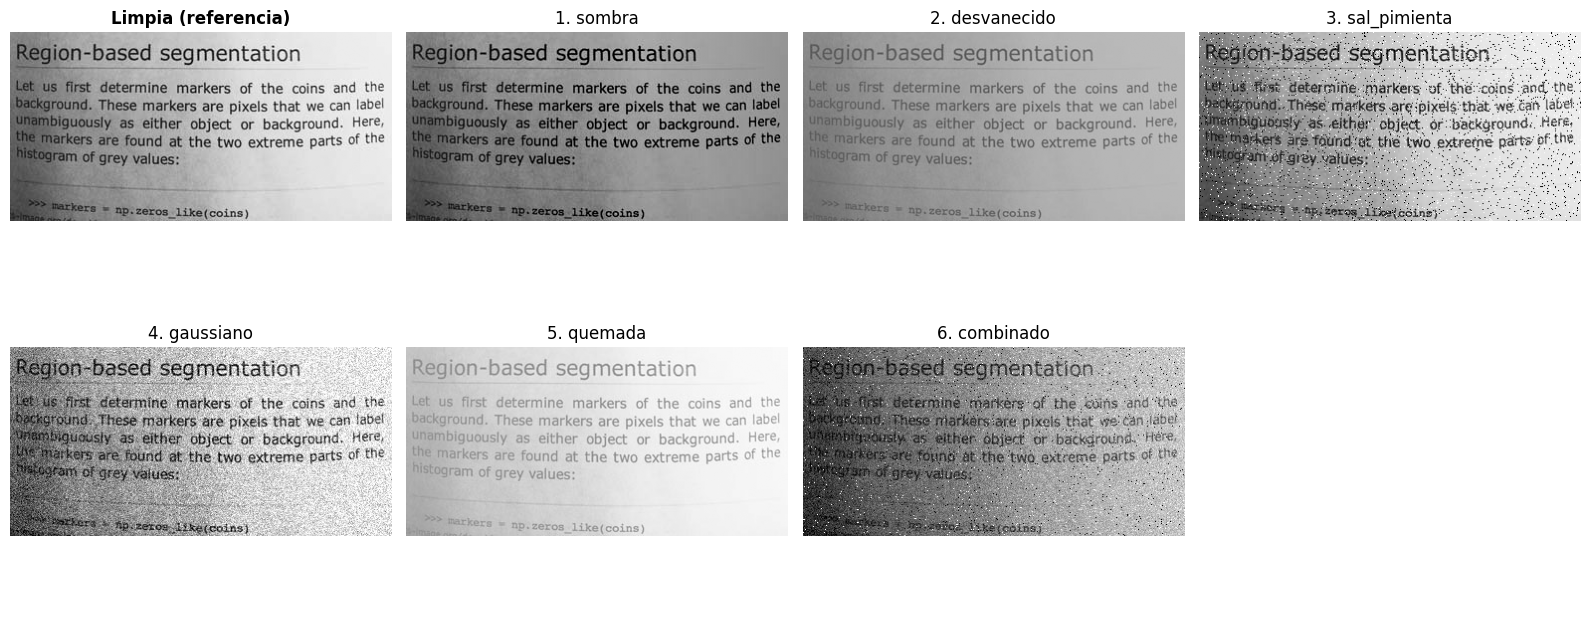


Dataset generado: 6 imágenes degradadas


In [ ]:
np.random.seed(42)  # reproducibilidad

def cargar_limpia():
    """Imagen base de un documento (texto sobre papel)."""
    return data.page()

def degradar_imagen(img, tipo):
    """Aplica una degradación específica para simular un escaneo defectuoso."""
    h, w = img.shape
    out = img.astype(float).copy()

    if tipo == 'sombra':
        sombra = np.tile(np.linspace(0, 90, w), (h, 1))
        out = out - sombra
    elif tipo == 'desvanecido':
        out = out * 0.45 + 80
    elif tipo == 'sal_pimienta':
        out = util.random_noise(out/255, mode='s&p', amount=0.06) * 255
    elif tipo == 'gaussiano':
        out = util.random_noise(out/255, mode='gaussian', var=0.012) * 255
    elif tipo == 'quemada':
        out = out * 0.5 + 130
    elif tipo == 'combinado':
        sombra = np.tile(np.linspace(0, 60, w), (h, 1))
        out = (out * 0.6 + sombra)
        out = util.random_noise(out/255, mode='gaussian', var=0.005) * 255
        out = util.random_noise(out/255, mode='s&p', amount=0.02) * 255

    return np.clip(out, 0, 255).astype(np.uint8)

limpia = cargar_limpia()
tipos = ['sombra', 'desvanecido', 'sal_pimienta', 'gaussiano', 'quemada', 'combinado']
dataset = {t: degradar_imagen(limpia, t) for t in tipos}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes[0,0].imshow(limpia, cmap='gray', vmin=0, vmax=255)
axes[0,0].set_title('Limpia (referencia)', fontweight='bold')
axes[0,0].axis('off')

for i, t in enumerate(tipos):
    ax = axes.flat[i+1]
    ax.imshow(dataset[t], cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{i+1}. {t}')
    ax.axis('off')
axes[1,3].axis('off')
plt.tight_layout(); plt.show()

print(f'\nDataset generado: {len(dataset)} imágenes degradadas')

---

# Diagnóstico

**Objetivo:** entender bien qué tienes en las manos antes de procesar nada. Un buen diagnóstico vale más que aplicar técnicas a ciegas.

**Conexión con capítulos previos:**
- *Cap. 1:* leer las propiedades básicas (dtype, shape, rango).
- *Cap. 2:* explorar la estructura matricial, hacer recortes, mirar histogramas.
- *Cap. 3:* identificar tipo de problema visualmente y por histograma.

## 1.1  Inspección básica (Cap. 1)

**Indicación:** completa la función para que devuelva las propiedades básicas de cada imagen del dataset.

In [ ]:
# TODO: reemplaza los placeholders por las propiedades reales de la imagen.
#       Debes devolver shape, dtype, min, max y mean.

def inspeccionar(img):
    """Devuelve un diccionario con propiedades básicas de una imagen."""
    # PLACEHOLDER: valores dummy para que el notebook corra. Reemplaza por los reales.
    return {
        'shape': img.shape,    # TODO: usa img.shape
        'dtype': img.dtype,    # TODO: usa img.dtype
        'min':   img.min(),    # TODO: usa img.min()
        'max':   img.max(),    # TODO: usa img.max()
        'mean':   round(float(img.mean()), 1),   # TODO: usa round(img.mean(), 1)
    }

print(f"{'tipo':<15} {'shape':<14} {'dtype':<14} {'min':>5} {'max':>5} {'mean':>7}")
print('-' * 64)
for t, img in dataset.items():
    r = inspeccionar(img)
    print(f"{t:<15} {str(r['shape']):<14} {str(r['dtype']):<14} {r['min']:>5} {r['max']:>5} {r['mean']:>7}")

# Test: si todavía es placeholder, te avisa.
if inspeccionar(limpia)['shape'] == (0, 0):
    print('\n[!] La función inspeccionar() todavía devuelve placeholders. Complétala.')

tipo            shape          dtype            min   max    mean
----------------------------------------------------------------
sombra          (191, 384)     uint8              0   200   126.4
desvanecido     (191, 384)     uint8             80   194   156.7
sal_pimienta    (191, 384)     uint8              0   255   168.8
gaussiano       (191, 384)     uint8              0   255   170.2
quemada         (191, 384)     uint8            130   255   215.5
combinado       (191, 384)     uint8              0   255   132.4


**Pregunta 1.1.** Mirando la tabla anterior, ¿qué imagen tiene el rango de intensidades más reducido? ¿Qué te dice eso sobre su problema?


La imagen de tipo desvanecido tiene el rango de intensidades más reducido [80-194], ya que los niveles de gris no ocupan todo el rango posible que es de  0 a 255, sino que están concentrados en valores intermedios. Como consecuencia, las diferencias entre el texto y el fondo de la imagen se reducen, haciendo que el texto se vea apagado y tienda a mezclarse con el fondo.

## 1.2  Exploración con histogramas (Cap. 3)

**Indicación:** dibuja la imagen y su histograma para cada una de las 6 imágenes. Esta es la parte más importante del diagnóstico: el histograma te dice el problema antes de mirar la imagen.

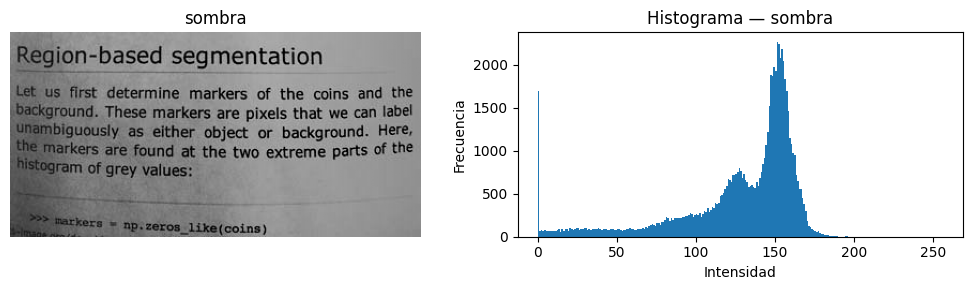

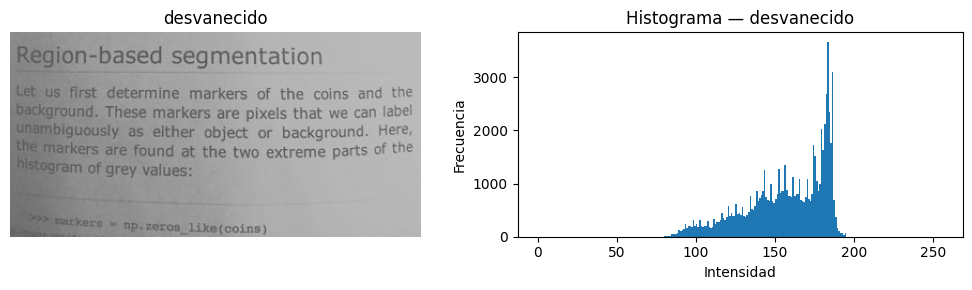

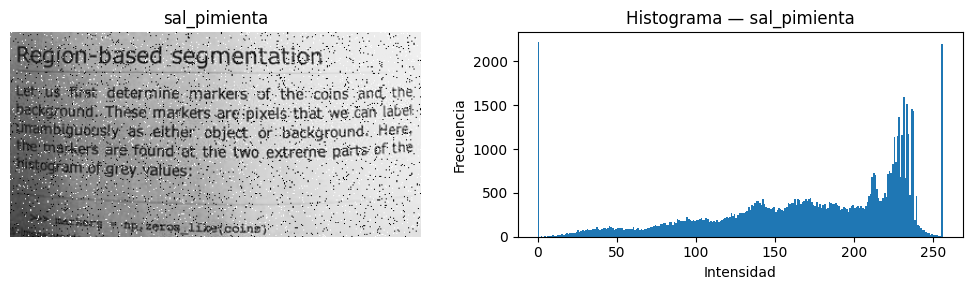

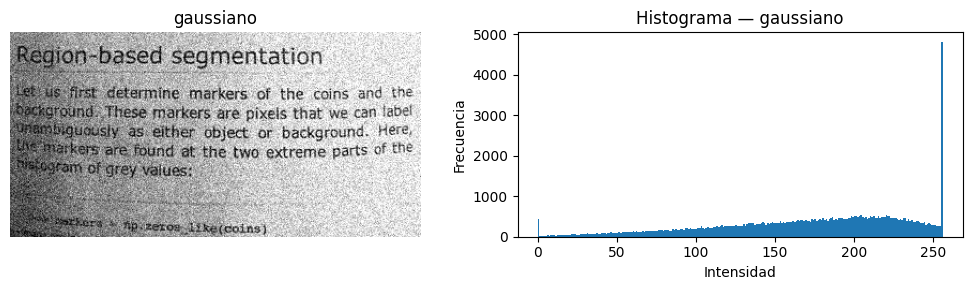

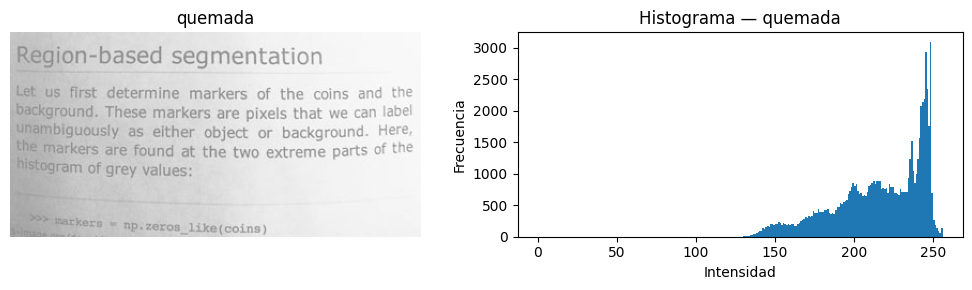

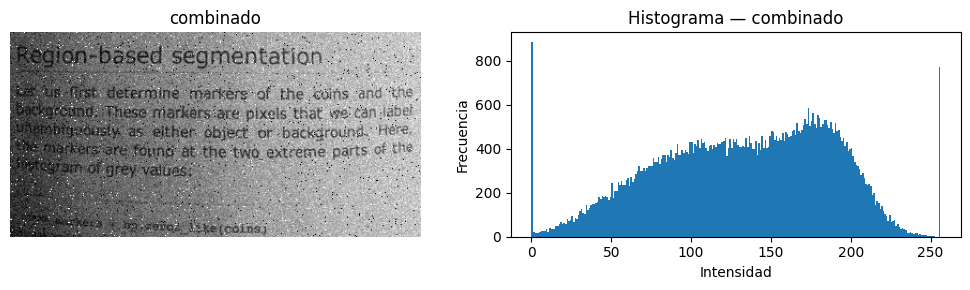

In [ ]:
# TODO: completa la función para mostrar imagen + histograma lado a lado.
#       Debe usar 256 bins en el rango [0, 256].

def imagen_e_histograma(img, titulo=''):
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))

    # TODO: en ax[0] muestra la imagen en escala de grises (vmin=0, vmax=255)
    ax[0].imshow(img, cmap='gray', vmin=0, vmax=255)

    # TODO: en ax[1] dibuja el histograma con 256 bins en rango (0, 256)
    ax[1].hist(img.ravel(), bins=256, range=(0, 256))

    ax[0].set_title(titulo); ax[0].axis('off')
    ax[1].set_title(f'Histograma — {titulo}')
    ax[1].set_xlabel('Intensidad'); ax[1].set_ylabel('Frecuencia')
    plt.tight_layout(); plt.show()

for t, img in dataset.items():
    imagen_e_histograma(img, t)

**Pregunta 1.2.** Para cada una de las 6 imágenes, completa la siguiente tabla con tu diagnóstico. Usa el patrón del histograma para justificar.

| # | Imagen | Forma del histograma | Problema identificado | Técnica que probaría primero |
|---|---|---|---|---|
| 1 | sombra | _(¿sesgado? ¿bimodal?)_ | _(tu diagnóstico)_ | _(ej. umbral adaptativo)_ |
| 2 | desvanecido | | | |
| 3 | sal_pimienta | | | |
| 4 | gaussiano | | | |
| 5 | quemada | | | |
| 6 | combinado | | | |

Copia esta tabla a la celda de respuesta y complétala.

| # | Imagen | Forma del histograma | Problema identificado | Técnica que probaría primero |
|---|---|---|---|---|
| 1 | sombra | Sesgado a la izquierda | Iluminación no uniforme | Umbralización Adaptativa |
| 2 | desvanecido | Concentrado al centro | Bajo contraste | Estiramiento de Contraste (Min-Max) |
| 3 | sal_pimienta | Bimodal extrema (0 y 255)| Ruido impulsivo que sustituye píxeles | Filtro de Mediana |
| 4 | gaussiano | Campana ancha y rugosa | Ruido aditivo distribuido normalmente | Filtro de Promedio |
| 5 | quemada | Sesgada a la derecha | Sobreexposición masiva | Transformación Gamma ($\gamma > 1$) |
| 6 | combinado | Multimodal, ruidoso y con picos extremos | Degradación multivariante (ruido mixto e iluminación no uniforme). | Filtro de Mediana para el ruido, seguido de Umbralización Adaptativa. |

## 1.3  Análisis matricial (Cap. 2)

**Indicación:** una imagen es una matriz. Vamos a confirmarlo extrayendo y analizando un parche pequeño.

In [ ]:
# TODO: extrae un parche 8x8 de la imagen 'gaussiano' (la del ruido)
# en la posición [100:108, 100:108]. Haz lo mismo para la imagen limpia.
# La desviación estándar de un parche que debería ser uniforme es una
# medida directa del nivel de ruido.

# PLACEHOLDER: parches dummy para que la celda no rompa.
parche_ruido  = dataset['gaussiano'][100:108, 100:108]   # TODO: dataset['gaussiano'][100:108, 100:108]
parche_limpio = limpia[100:108, 100:108]  # TODO: limpia[100:108, 100:108]

print('Parche 8x8 (ruidoso):')
print(parche_ruido)
print(f'\nMedia parche ruidoso:  {parche_ruido.mean():.2f}')
print(f'Std   parche ruidoso:  {parche_ruido.std():.2f}  (proporcional al nivel de ruido)')
print(f'Std   parche limpio:   {parche_limpio.std():.2f}')
print(f'Diferencia (aprox. desviacion del ruido): {parche_ruido.std() - parche_limpio.std():.2f}')

if parche_ruido.sum() == 0:
    print('\n[!] Los parches son placeholders. Reemplaza por los slices reales.')

Parche 8x8 (ruidoso):
[[137 168 131  95 107 150 149 147]
 [128 112 178 122 153 108 118 142]
 [ 94 131 146 185 143 166 151 106]
 [134 143 127 171 162 118 174 129]
 [160  81 129 144 135 198 156 146]
 [ 98 163  93 155 127 157 159 171]
 [144 134  91 132 136 124  98 151]
 [ 38  66 140 119  57  46  63  41]]

Media parche ruidoso:  129.33
Std   parche ruidoso:  34.82  (proporcional al nivel de ruido)
Std   parche limpio:   28.53
Diferencia (aprox. desviacion del ruido): 6.29


**Pregunta 1.3.** En el Cap. 2 vimos que sumar dos imágenes es sumar matrices elemento a elemento. La imagen `gaussiano` la generamos como `imagen_limpia + ruido`. Demuestra esto numéricamente: calcula `dataset['gaussiano'] - limpia` (con cuidado del dtype, conviértelas a `int16` para evitar desbordes) y verifica que el resultado tenga media cercana a cero y std consistente con el ruido.

In [ ]:
# TODO: tu código aquí
# Ejemplo de inicio:
#   diferencia = dataset['gaussiano'].astype(np.int16) - limpia.astype(np.int16)
#   print('Media de la diferencia:', diferencia.mean())
#   print('Std de la diferencia:  ', diferencia.std())

diferencia = dataset['gaussiano'].astype(np.int16) - limpia.astype(np.int16)
print('Media de la diferencia:', diferencia.mean())
print('Std de la diferencia:  ', diferencia.std())


Media de la diferencia: -1.2951570680628273
Std de la diferencia:   26.594019626704075


**Observaciones:** Los resultados muestran que la imagen con ruido gaussiano se comporta como la suma de la imagen original más una señal de ruido. La media de la diferencia es cercana a cero, lo que indica que el ruido no cambia el brillo general de la imagen.

Por su parte, la desviación estándar representa la cantidad de ruido añadido, es decir, cuánto varían los píxeles por efecto del ruido. La pequeña desviación de la media respecto a cero se debe a efectos como el redondeo y el límite de valores entre 0 y 255. En conjunto, esto confirma que el ruido es aditivo y está distribuido sobre toda la imagen.


---

# Transformaciones de intensidad (Cap. 3, Bloque 2)

**Objetivo:** resolver las imágenes 1, 2 y 5 (sombra, desvanecido, quemada). Implementar al menos una transformación de intensidad **desde cero**.

Vas a implementar tres herramientas y aplicarlas en orden creciente de sofisticación: lineal, gamma y umbralización.

## 2.1  Transformación lineal desde cero (requisito)

**Indicación:** implementa `s = a·r + b` con saturación correcta. Esta función es trivial pero es la base de todo lo que sigue. Implementarla bien (con clip) es la diferencia entre un pipeline que funciona y uno con artefactos misteriosos.

In [ ]:
# TODO: implementa la transformación lineal desde cero.
#       NO uses skimage para esto. Solo NumPy.

def transf_lineal(img, a=1.0, b=0):
    """Aplica s = a*r + b con saturación a [0, 255]."""
    # Pasos:
    # 1) Convertir img a float (para que la aritmética no se desborde)
    # 2) Calcular salida = a * img + b
    # 3) Saturar a [0, 255] con np.clip
    # 4) Devolver como uint8

    # PLACEHOLDER: devuelve la imagen sin tocar.
    img_float = img.astype(np.float32)
    salida = a * img_float + b
    salida = np.clip(salida, 0, 255)

    return salida.astype(np.uint8)

# Test rápido
test = np.array([[0, 100, 200, 255]], dtype=np.uint8)
r1 = transf_lineal(test, a=1, b=50)
r2 = transf_lineal(test, a=2, b=0)
r3 = transf_lineal(test, a=0.5, b=30)
print('Test +50:    ', r1, ' (esperado: [[ 50 150 250 255]])')
print('Test x2:     ', r2, ' (esperado: [[  0 200 255 255]])')
print('Test x0.5+30:', r3, ' (esperado: [[ 30  80 130 158]])')

if np.array_equal(r1, test):
    print('\n[!] transf_lineal() todavía devuelve la imagen sin tocar. Complétala.')

Test +50:     [[ 50 150 250 255]]  (esperado: [[ 50 150 250 255]])
Test x2:      [[  0 200 255 255]]  (esperado: [[  0 200 255 255]])
Test x0.5+30: [[ 30  80 130 157]]  (esperado: [[ 30  80 130 158]])


**Pregunta 2.1.** ¿Qué pasaría si no hicieras `np.clip`? Prueba aplicar `transf_lineal(img, a=2, b=0)` sin el clip a una imagen brillante y mira los píxeles que pasan de 255. ¿Qué valores aparecen?

In [ ]:
# TODO: demuestra el desborde sin clip aquí
# Pista: si haces (img.astype(np.uint8) * 2) directamente, el uint8 desborda en módulo 256.
# Toma un array con valor 200 y multiplícalo por 2 sin convertir a float.

test = np.array([200], dtype=np.uint8)
resultado = test * 2

print(f'Valor original (uint8):       {test}')
print(f'Multiplicado por 2 (sin float ni clip): {resultado} (Esperado: 400 % 256 = 144)')

# Comparamos con transf_lineal que sí usa float y clip
resultado_con_transf = transf_lineal(test, a=2, b=0)
print(f'Con transf_lineal (float y clip):   {resultado_con_transf} (Esperado: 255)')

Valor original (uint8):       [200]
Multiplicado por 2 (sin float ni clip): [144] (Esperado: 400 % 256 = 144)
Con transf_lineal (float y clip):   [255] (Esperado: 255)


**RESPUESTA:** Si no se aplica np.clip, los valores que superan 255 no se saturan, sino que se desbordan debido al tipo uint8, que trabaja en módulo 256. Por ejemplo, 200 × 2 = 400, pero en uint8 se convierte en 144 (400%256). Esto genera valores incorrectos y artefactos en la imagen, ya que píxeles brillantes pueden transformarse en tonos más oscuros.

## 2.2  Transformación gamma desde cero (requisito)

**Indicación:** implementa `s = c · r^γ`. Recuerda que **debes normalizar a [0, 1]** antes de elevar a potencia, o vas a obtener resultados absurdos.

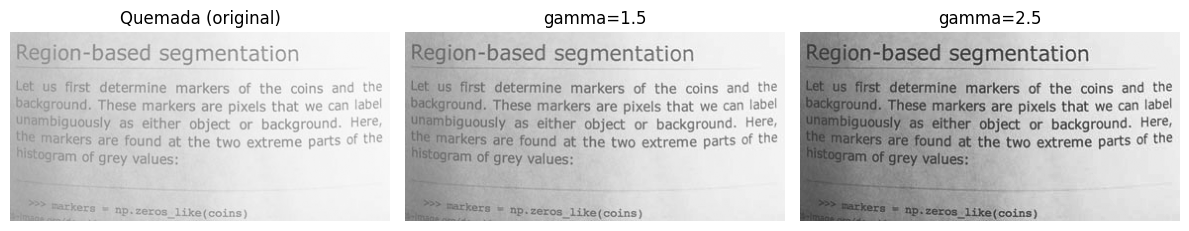

In [ ]:
# TODO: implementa la transformación gamma desde cero.

def transf_gamma(img, gamma=1.0, c=1.0):
    """Aplica s = c * r^gamma.

    Pasos:
    1) Normalizar img de [0, 255] a [0, 1]
    2) Aplicar la potencia
    3) Multiplicar por c y por 255 para volver a [0, 255]
    4) Saturar y devolver uint8
    """
    # PLACEHOLDER
    img_norm = img.astype(np.float32) / 255.0
    salida = c * (img_norm ** gamma)
    salida = salida * 255.0
    salida = np.clip(salida, 0, 255)
    return salida.astype(np.uint8)

quemada = dataset['quemada']
comparar(
    [quemada, transf_gamma(quemada, gamma=1.5), transf_gamma(quemada, gamma=2.5)],
    ['Quemada (original)', 'gamma=1.5', 'gamma=2.5']
)

# Test
if np.array_equal(transf_gamma(quemada, gamma=2.5), quemada):
    print('[!] transf_gamma() todavía es placeholder.')

**Pregunta 2.2.** Tu imagen de prueba es `quemada` (sobreexpuesta). Para corregirla necesitas oscurecerla, lo que requiere γ ¿menor o mayor que 1? Justifica con la curva gamma.

**Respuesta:**

Para corregir una imagen sobreexpuesta, se necesita un valor de $\gamma$ mayor que 1.Esto se debe a que, en la transformación $s = r^\gamma$, cuando $\gamma > 1$, la curva de transferencia es convexa y se sitúa por debajo de la línea de identidad ($s = r$). Como consecuencia, la mayoría de los niveles de gris se desplazan hacia valores más oscuros, reduciendo el brillo global de la imagen. Esto permite "estirar" el contraste en las zonas claras, recuperando detalles del texto que antes se perdían por la saturación de blancos. Por el contrario, un $\gamma < 1$ generaría una curva cóncava que aclararía la imagen aún más, agravando la sobreexposición.

## 2.3  Resolver imagen `desvanecido`

**Indicación:** la imagen 'desvanecido' tiene bajo contraste (la tinta se ve gris, no negra). Encuentra la combinación de `transf_lineal` o `transf_gamma` que la mejore. Usa PSNR/SSIM contra `limpia` para guiar tu elección.

Reto extra: prueba al menos 3 combinaciones y elige la mejor.

metodo             PSNR (dB)       SSIM
----------------------------------------
sin restaurar          17.35     0.8438
Lineal Fuerte          38.71     0.9973
Gamma Elevado           6.18     0.4191
Híbrido L+G            20.41     0.9777


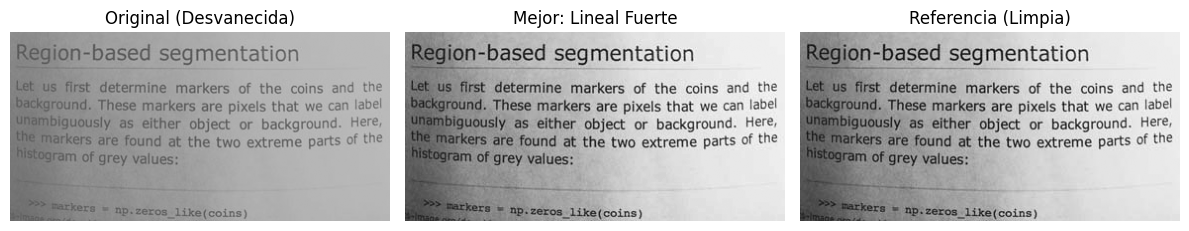

In [ ]:
desvanecida = dataset['desvanecido']

# TODO: prueba al menos 3 combinaciones distintas y reporta sus métricas.
# Sugerencia: combina lineal (estirar contraste) con gamma.
# Por ejemplo:
#   'opcion A': transf_lineal(desvanecida, a=2.0, b=-100)
#   'opcion B': transf_gamma(desvanecida, gamma=2.0)
#   'opcion C': transf_gamma(transf_lineal(desvanecida, a=1.5, b=-50), gamma=1.5)
candidatos = {
    'Lineal Fuerte': transf_lineal(desvanecida, a=2.2, b=-170),  # TODO: reemplaza por una versión restaurada
    'Gamma Elevado': transf_gamma(desvanecida, gamma=3.5),  # TODO
    'Híbrido L+G':  transf_gamma(transf_lineal(desvanecida, a=1.8, b=-120), gamma=1.2)  # TODO
}

# Calcular métricas e identificar la mejor opción
best_name = None
best_psnr = -1
best_img = None

print(f"{'metodo':<15} {'PSNR (dB)':>12} {'SSIM':>10}")
print('-' * 40)

# Métrica base
p_orig, s_orig = metricas(limpia, desvanecida)
print(f'{"sin restaurar":<15} {p_orig:>12.2f} {s_orig:>10.4f}')

for nombre, img in candidatos.items():
    p, s = metricas(limpia, img)
    print(f'{nombre:<15} {p:>12.2f} {s:>10.4f}')

    if p > best_psnr:
        best_psnr = p
        best_name = nombre
        best_img = img

# Visualizar la comparación
comparar(
    [desvanecida, best_img, limpia],
    ['Original (Desvanecida)', f'Mejor: {best_name}', 'Referencia (Limpia)']
)

**Pregunta 2.3.** ¿Qué combinación funcionó mejor? ¿Por qué crees que esa fue la mejor? No respondas "porque tuvo mayor PSNR" — explica el porqué técnico.

**RESPUESTA:**

La combinación que funcionó mejor fue la transformación lineal fuerte, ya que el problema principal de la imagen era el bajo contraste (rango dinámico estrecho). Esta técnica expande las intensidades de un intervalo reducido al rango completo $[0, 255]$. Al ser una función lineal, esta técnica preservó la proporcionalidad de las intensidades y la integridad de los bordes del texto, lo que se refleja en un SSIM de 0.9973, indicando una reconstrucción estructural casi idéntica a la referencia. A diferencia de la transformación gamma, que introduce distorsiones no lineales, el ajuste lineal permitió recuperar negros puros y blancos brillantes sin alterar la morfología de las letras.

## 2.4  Umbralización para imagen `sombra`

**Indicación:** la imagen 'sombra' es el ejemplo clásico de iluminación desigual. Compara umbral global (Otsu) vs umbral adaptativo y reporta cuál funciona mejor. No tienes que implementar Otsu desde cero, puedes usar `skimage.filters.threshold_otsu` y `threshold_local`.

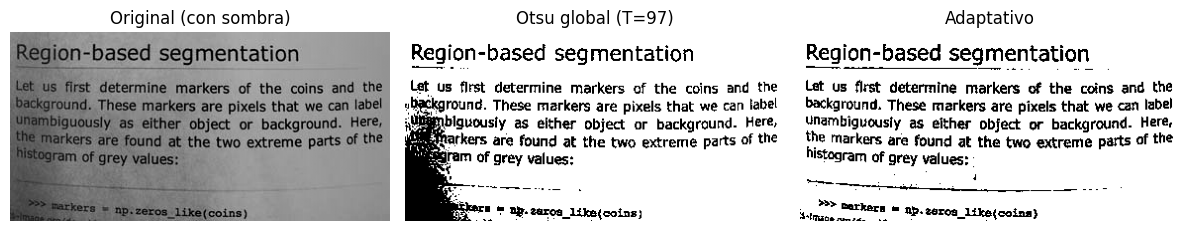

In [ ]:
from skimage.filters import threshold_otsu, threshold_local

img_sombra = dataset['sombra']

# TODO: aplica umbral global con Otsu
T_global   = threshold_otsu(img_sombra)
bin_global = (img_sombra > T_global).astype(np.uint8) * 255

# TODO: aplica umbral adaptativo (block_size=51, offset=10)
T_local   = threshold_local(img_sombra, block_size=51, offset=10)
bin_local = (img_sombra > T_local).astype(np.uint8) * 255

comparar(
    [img_sombra, bin_global, bin_local],
    ['Original (con sombra)', f'Otsu global (T={T_global})', 'Adaptativo']
)

**Pregunta 2.4.** Mirando los resultados, ¿qué pasa con el umbral global? ¿Por qué exactamente falla? Explica usando el concepto de histograma local vs. histograma global.

**RESPUESTA:**

El umbral global falla porque intenta separar el texto del fondo usando un único valor de intensidad para toda la imagen, lo cual no funciona bien con iluminación no uniforme. En el histograma global, las intensidades del fondo en zonas con sombra se solapan con las del texto en zonas iluminadas, haciendo difícil encontrar un umbral que no pierda información o genere errores. En cambio, la técnica adaptativa calcula umbrales locales en pequeñas regiones, donde el contraste entre texto y fondo es más consistente, permitiendo una mejor separación y recuperación del texto en toda la imagen.

---

# Histogramas y ecualización (Cap. 3, Bloque 3)

**Objetivo:** dominar la ecualización. Implementarla **desde cero** (requisito) y comparar contra CLAHE.

Esta es la sección donde el Cap. 3 muestra su poder real.

## 3.1  Ecualización de histograma desde cero (requisito)

**Indicación:** implementa la ecualización siguiendo los 5 pasos vistos en clase. Sin usar `skimage.exposure.equalize_hist`.

Recordatorio de los pasos:
1. Calcular el **histograma** (conteo por nivel).
2. Calcular la **PDF** (probabilidad: hist / N).
3. Calcular la **CDF** (acumulada de la PDF).
4. Construir la **LUT**: `lut[k] = round(cdf[k] · 255)`.
5. **Aplicar la LUT**: `out[i,j] = lut[img[i,j]]`.

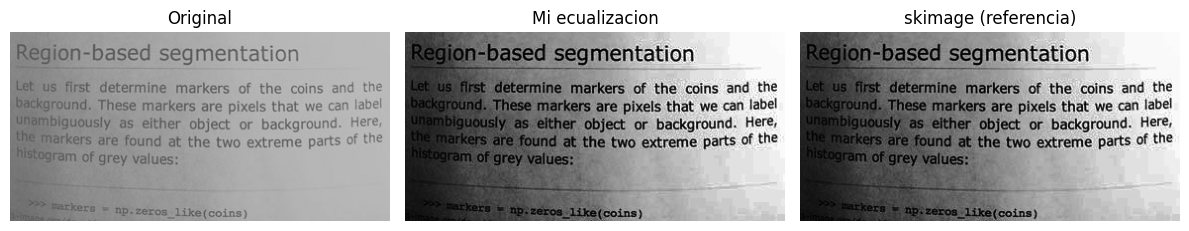

In [ ]:
# TODO: implementa ecualización de histograma desde cero.
#       Tu única dependencia permitida es np.histogram (o el conteo manual).

def ecualizar(img):
    """Ecualiza el histograma de una imagen 8-bit."""
    # Paso 1: histograma con 256 bins
    hist, _ = np.histogram(img.ravel(), bins=256, range=(0, 256))

    # Paso 2: PDF
    pdf = hist / img.size

    # Paso 3: CDF (pista: np.cumsum)
    cdf = pdf.cumsum()

    # Paso 4: LUT
    lut = np.round(cdf * 255).astype(np.uint8)

    # Paso 5: aplicar LUT (fancy indexing)
    return lut[img]


# Test: aplica a 'desvanecido' y compara contra skimage
from skimage.exposure import equalize_hist
mio = ecualizar(dataset['desvanecido'])
ref = (equalize_hist(dataset['desvanecido']) * 255).astype(np.uint8)

comparar(
    [dataset['desvanecido'], mio, ref],
    ['Original', 'Mi ecualizacion', 'skimage (referencia)']
)

if np.array_equal(mio, dataset['desvanecido']):
    print('[!] ecualizar() todavía es placeholder.')

**Pregunta 3.1.** Visualiza los histogramas antes y después de ecualizar. ¿Por qué el histograma resultante no es perfectamente plano? Pista: la ecualización trabaja con valores discretos.

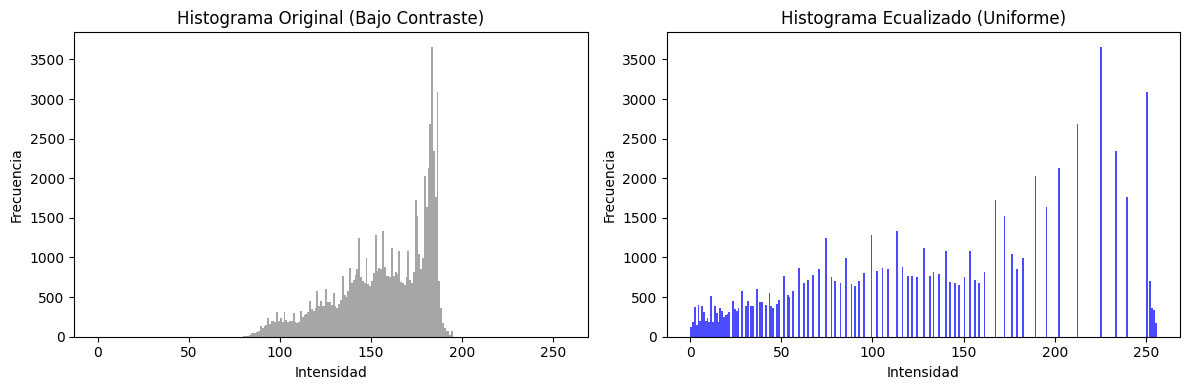

In [ ]:
# TODO: dibuja los dos histogramas (antes y después) en una sola figura
# Pista: plt.subplots(1, 2, figsize=(10, 3)) y luego ax[0].hist(...) ax[1].hist(...)

img_desvanecida = dataset['desvanecido']
img_equalizada = ecualizar(img_desvanecida)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(img_desvanecida.ravel(), bins=256, range=(0, 256), color='gray', alpha=0.7)
ax[0].set_title('Histograma Original (Bajo Contraste)')
ax[0].set_xlabel('Intensidad')
ax[0].set_ylabel('Frecuencia')

ax[1].hist(img_equalizada.ravel(), bins=256, range=(0, 256), color='blue', alpha=0.7)
ax[1].set_title('Histograma Ecualizado (Uniforme)')
ax[1].set_xlabel('Intensidad')
ax[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

**RESPUESTA**

El histograma resultante no es perfectamente plano porque la imagen es una señal discreta y no continua. El algoritmo de ecualización utiliza una función de transferencia basada en la CDF que redistribuye los niveles de gris, pero no puede "separar" píxeles que originalmente tienen el mismo valor de intensidad. Por lo tanto, si un nivel de gris tiene una frecuencia muy alta, ese pico simplemente se desplazará a una nueva posición sin dividirse, manteniendo su altura. Además, al estirar un histograma originalmente comprimido sobre el rango $[0, 255]$, se crean espacios vacíos entre los niveles, ya que no es posible generar nuevos valores intermedios para rellenar los huecos. Por eso, aunque se busca uniformidad, no se logra un histograma perfectamente plano.

## 3.2  Comparación: ecualización global vs. CLAHE

**Indicación:** aplica las dos técnicas a la imagen `combinado` (la más realista) y compara visualmente y con métricas.

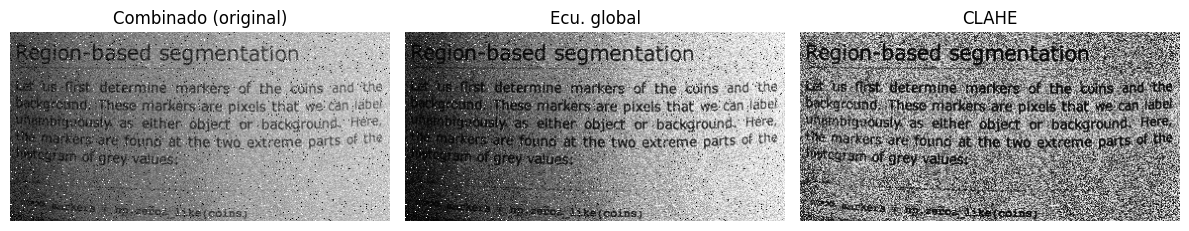

original        PSNR=14.15  SSIM=0.3644
ecu global      PSNR=12.87  SSIM=0.3247
CLAHE           PSNR=9.59  SSIM=0.2635


In [ ]:
from skimage.exposure import equalize_adapthist

img_comb = dataset['combinado']

# TODO: aplica tu función ecualizar() a img_comb
ecu_global = ecualizar(img_comb)  # TODO: ecualizar(img_comb)

# TODO: aplica CLAHE con clip_limit=0.03
ecu_clahe = (equalize_adapthist(img_comb, clip_limit=0.03) * 255).astype(np.uint8)   # TODO: (equalize_adapthist(img_comb, clip_limit=0.03) * 255).astype(np.uint8)

comparar(
    [img_comb, ecu_global, ecu_clahe],
    ['Combinado (original)', 'Ecu. global', 'CLAHE']
)

for nombre, img in [('original', img_comb), ('ecu global', ecu_global), ('CLAHE', ecu_clahe)]:
    p, s = metricas(limpia, img)
    print(f'{nombre:<15} PSNR={p:.2f}  SSIM={s:.4f}')

**Pregunta 3.2.** Observa los resultados. ¿En qué se diferencia visualmente el resultado de CLAHE vs ecualización global? ¿Qué métrica refleja mejor esa diferencia?

**RESPUESTA**

La ecualización global no corrige bien la iluminación desigual, deja una parte muy oscura y otra muy clara, perdiendo información. En cambio, CLAHE mejora el contraste en toda la imagen y hace el texto más visible en todas las zonas, pero tiene el problema de amplificar el ruido, generando más grano en el fondo.

En cuanto a métricas, el PSNR baja porque el ruido introduce muchas diferencias píxel a píxel. El SSIM es más útil aquí porque evalúa si las letras siguen siendo reconocibles. Aunque la ecualización global tiene un SSIM ligeramente mayor, CLAHE puede distorsionar los caracteres cuando el ruido es alto, debido a su ajuste local más agresivo.

---

# Filtros espaciales (Cap. 3, Bloques 4-5)

**Objetivo:** aplicar filtros para resolver las imágenes 3 y 4 (sal_pimienta y gaussiano). Implementar un filtro convolucional **desde cero** (requisito).

Conexión con Cap. 2: convolución y vecindades.

## 4.1  Filtro de media desde cero (requisito)

**Indicación:** implementa un filtro de media de tamaño `k×k` aplicando convolución manualmente. Puedes usar `scipy.ndimage.convolve` para la convolución, pero el kernel y la lógica son tuyos.

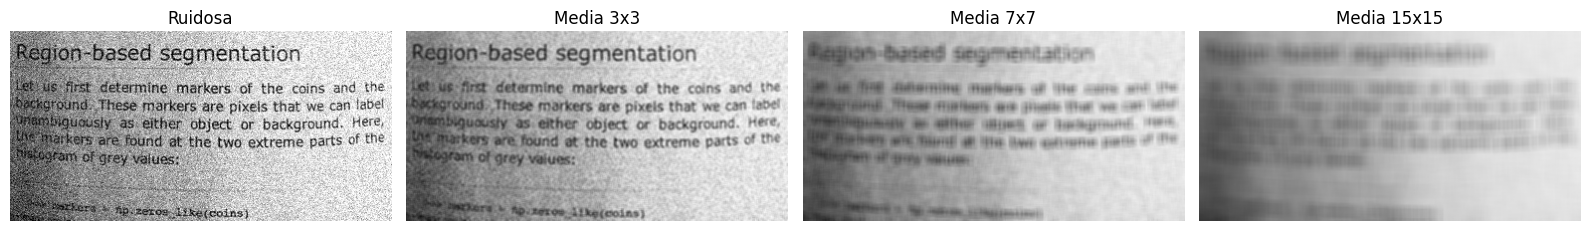

In [ ]:
# TODO: implementa el filtro de media desde cero.
#       Construye el kernel manualmente; no uses ndi.uniform_filter.

def filtro_media(img, k=3):
    """Aplica un filtro de media k x k."""
    # Pasos:
    # 1) Construir kernel k×k de unos, dividido por k*k
    kernel = np.ones((k, k)) / (k*k)
    # 2) Convolución (con padding 'reflect')
    salida = ndi.convolve(img.astype(float), kernel, mode='reflect')
    # 3) Saturar y devolver uint8
    return np.clip(salida, 0, 255).astype(np.uint8)


ruidosa = dataset['gaussiano']
comparar(
    [ruidosa, filtro_media(ruidosa, 3), filtro_media(ruidosa, 7), filtro_media(ruidosa, 15)],
    ['Ruidosa', 'Media 3x3', 'Media 7x7', 'Media 15x15']
)

if np.array_equal(filtro_media(ruidosa, 7), ruidosa):
    print('[!] filtro_media() todavía es placeholder.')

**Pregunta 4.1.** Reporta PSNR y SSIM para los tres tamaños de ventana (3, 7, 15) en la imagen `gaussiano`. ¿Cuál tiene el mejor PSNR? ¿Cuál se ve mejor a simple vista? ¿Por qué a veces no coinciden?

In [ ]:
# TODO: tabla de PSNR/SSIM por tamaño de ventana
# Pista:
#   for k in [3, 7, 15]:
#       p, s = metricas(limpia, filtro_media(ruidosa, k))
#       print(f'k={k:2d}  PSNR={p:.2f}  SSIM={s:.4f}')

print(f"{'Tamaño (k)':<12} {'PSNR (dB)':>12} {'SSIM':>10}")
print('-' * 35)

for k in [3, 7, 15]:
    img_filtrada = filtro_media(ruidosa, k)
    p, s = metricas(limpia, img_filtrada)
    print(f'k={k:2d}x{k:2d}      {p:>12.2f} {s:>10.4f}')

Tamaño (k)      PSNR (dB)       SSIM
-----------------------------------
k= 3x 3             21.13     0.5830
k= 7x 7             18.17     0.4836
k=15x15             17.57     0.4479


**RESPUESTA**

La ventana de 3x3 ofrece el mejor resultado tanto en métricas como visualmente, ya que reduce el ruido sin afectar demasiado el texto. Al aumentar el tamaño a 7x7 o 15x15, la imagen se vuelve borrosa y las métricas caen, ya que el filtro de media elimina no solo el ruido, sino también los bordes de las letras. Esto ocurre porque al ser un filtro de paso bajo, suaviza las altas frecuencias donde reside la información crítica del texto, lo que demostra que un exceso de filtrado puede ser tan perjudicial como el ruido mismo.

## 4.2  Filtro de mediana para sal y pimienta

**Indicación:** aplica filtro de mediana a la imagen `sal_pimienta` y compáralo contra el filtro de media. Usa `skimage.filters.median` con `disk(1)` (vecindad 3×3).

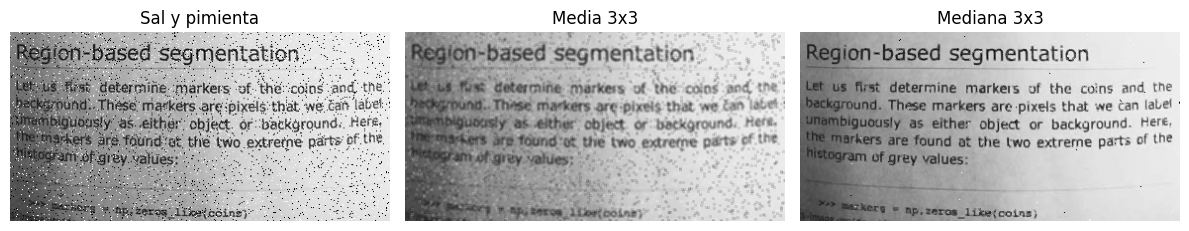

original   PSNR=17.02  SSIM=0.4400
media      PSNR=20.42  SSIM=0.5219
mediana    PSNR=25.69  SSIM=0.9204


In [ ]:
from skimage.filters import median
from skimage.morphology import disk

img_sp = dataset['sal_pimienta']

# TODO: aplica filtro de media 3x3
limpia_media   = filtro_media(img_sp, 3)  # TODO: filtro_media(img_sp, 3)

# TODO: aplica filtro de mediana con disk(1)
limpia_mediana = median(img_sp, disk(1))  # TODO: median(img_sp, disk(1))

comparar(
    [img_sp, limpia_media, limpia_mediana],
    ['Sal y pimienta', 'Media 3x3', 'Mediana 3x3']
)

for nombre, img in [('original', img_sp), ('media', limpia_media), ('mediana', limpia_mediana)]:
    p, s = metricas(limpia, img)
    print(f'{nombre:<10} PSNR={p:.2f}  SSIM={s:.4f}')

**Pregunta 4.2.** Demuestra numéricamente por qué la mediana destruye outliers y la media no. Toma la vecindad 3×3 alrededor de un píxel "sal" (valor 255 rodeado de píxeles ~120) y calcula a mano el resultado de los dos filtros (mediana y media). Reporta los dos números.

In [ ]:
# TODO: demuestra numéricamente la diferencia
# Pista: encuentra un píxel sal (img == 255) y extrae su vecindad 3x3
# Por ejemplo:
#   coords = np.argwhere(img_sp == 255)
#   y, x = coords[10]  # toma uno cualquiera no en el borde
#   vec = img_sp[y-1:y+2, x-1:x+2]
#   print('Vecindad:', vec)
#   print('Media: ', vec.mean())
#   print('Mediana:', np.median(vec))

coords = np.argwhere(img_sp == 255)

for y, x in coords:
    if 1 <= y < img_sp.shape[0] - 1 and 1 <= x < img_sp.shape[1] - 1:

        vecindad = img_sp[y-1:y+2, x-1:x+2]

        res_media = vecindad.mean()
        res_mediana = np.median(vecindad)

        print("Vecindad 3x3 alrededor del outlier (Sal):")
        print(vecindad)
        print("-" * 35)
        print(f"Resultado Filtro de Media:   {res_media:.2f}")
        print(f"Resultado Filtro de Mediana: {res_mediana:.2f}")


        break



Vecindad 3x3 alrededor del outlier (Sal):
[[124 131 139]
 [127 255 139]
 [130 134 138]]
-----------------------------------
Resultado Filtro de Media:   146.33
Resultado Filtro de Mediana: 134.00


**RESPUESTA**

El filtro de media es sensible al ruido impulsivo, ya que al promediar un valor extremo (como “sal”) con sus vecinos, el resultado se desplaza y genera manchas que degradan la imagen. En cambio, el filtro de mediana es más robusto, porque ignora esos valores extremos y mantiene un valor representativo del entorno. Por eso, la mediana elimina mejor el ruido sin alterar la intensidad real de la zona, mientras que la media tiende a dispersar el error en los píxeles vecinos.

## 4.3  Afilado con unsharp masking

**Indicación:** después de suavizar, los bordes pierden definición. El unsharp masking los recupera. Implementa el algoritmo:

$$\hat{f} = f + k \cdot (f - f_{\text{blur}})$$

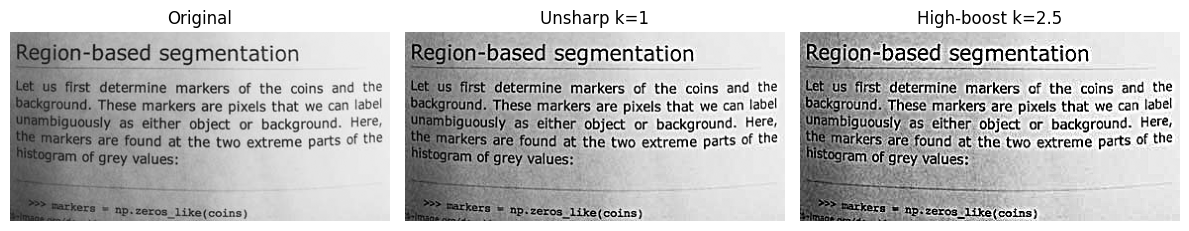

In [ ]:
from scipy.ndimage import gaussian_filter

# TODO: implementa unsharp masking.

def unsharp(img, sigma=2, k=1.0):
    """Aplica unsharp masking: f_hat = f + k*(f - f_blur)."""
    # 1) Calcular f_blur con gaussian_filter
    f = img.astype(np.float32)
    f_blur = gaussian_filter(f, sigma=sigma)
    # 2) Calcular detalle = f - f_blur
    detalle = f - f_blur
    # 3) Salida = f + k * detalle
    f_hat = f + k * detalle
    # 4) Saturar y devolver uint8

    return np.clip(f_hat, 0, 255).astype(np.uint8)

comparar(
    [limpia, unsharp(limpia, sigma=2, k=1), unsharp(limpia, sigma=2, k=2.5)],
    ['Original', 'Unsharp k=1', 'High-boost k=2.5']
)

**Pregunta 4.3.** Si subes `k` demasiado, aparece un artefacto reconocible llamado halo alrededor de los bordes. Pruébalo con `k=5` y descríbelo en una frase.

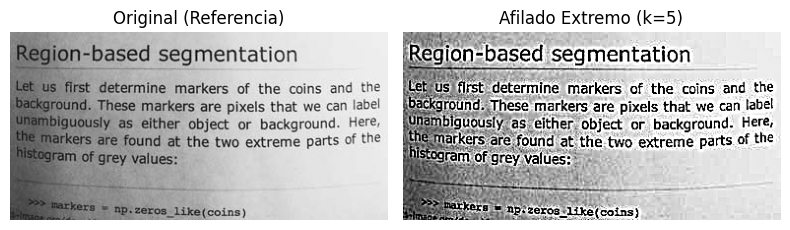

In [ ]:
# TODO: visualiza con k=5
img_k5 = unsharp(limpia, sigma=2, k=5)

comparar(
    [limpia, img_k5],
    ['Original (Referencia)', 'Afilado Extremo (k=5)']
)

**RESPUESTA**

Con un factor de ganancia alto ($k=5$), el realce sobrepasa el rango dinámico y genera halos brillantes alrededor del texto, saturando los píxeles y distorsionando la apariencia natural de los caracteres.

---

# Pipeline integrado

**Objetivo:** combinar todo en una sola función `restaurar_documento()` y aplicarla a las 6 imágenes. Discutir el orden de aplicación de las técnicas, que es donde está la sutileza.

## 5.1  La función maestra

**Indicación:** implementa una función que reciba una imagen y un perfil, y devuelva la imagen restaurada. Debes soportar al menos 4 perfiles.

In [ ]:
# TODO: implementa la función maestra de restauración.
#       Cada perfil debe combinar al menos 2 técnicas del Cap. 3.
#       Justifica brevemente cada elección con un comentario.

def restaurar_documento(img, perfil='completo'):
    """Pipeline de restauración para documentos históricos.

    Perfiles soportados:
      - 'sombra':       iluminación desigual
      - 'desvanecido':  bajo contraste
      - 'ruidoso':      ruido sal y pimienta o gaussiano
      - 'quemada':      sobreexposición
      - 'completo':     pipeline robusto que funciona razonablemente para todos
    """
    if perfil == 'sombra':
        # TODO: aplica las técnicas adecuadas y devuelve el resultado
        # Sugerencia: CLAHE para corregir iluminación local + suavizado leve
        res = (equalize_adapthist(img, clip_limit=0.03) * 255).astype(np.uint8)
        return unsharp(res, sigma=1, k=0.8)

    elif perfil == 'desvanecido':
        # TODO
        # Sugerencia: ecualización (tu función) o stretching lineal + gamma
        res = ecualizar(img)
        # Un leve ajuste Gamma (gamma < 1) puede ayudar a oscurecer más los trazos del texto.
        return transf_gamma(res, gamma=0.8)

    elif perfil == 'ruidoso':
        # TODO
        # Sugerencia: mediana primero (sal y pimienta) + gaussiano leve si queda ruido + CLAHE
        res = median(img, disk(1))
        return (equalize_adapthist(res, clip_limit=0.02) * 255).astype(np.uint8)

    elif perfil == 'quemada':
        # TODO
        # Sugerencia: gamma > 1 + ajuste lineal
        res = transf_gamma(img, gamma=1.5)
        return transf_lineal(res, a=1.2, b=-20)

    elif perfil == 'completo':
        # TODO: combina varias etapas en orden
        # 1. Denosing (Mediana) -> 2. Iluminación (CLAHE) -> 3. Realce (Unsharp)
        step1 = median(img, disk(1))
        step2 = (equalize_adapthist(step1, clip_limit=0.03) * 255).astype(np.uint8)
        step3 = unsharp(step2, sigma=1, k=1.2)
        return step3

    else:
        raise ValueError(f'Perfil desconocido: {perfil}')

print('Función definida')

Función definida


## 5.2  Aplicación a las 6 imágenes

**Indicación:** asigna a cada imagen el perfil que mejor le corresponda y mide la mejora.

In [ ]:
# TODO: asigna el perfil correcto a cada imagen
# Reemplaza 'completo' por el perfil específico que corresponda en cada caso.
asignacion = {
    'sombra':       'sombra',      # Corregir iluminación local desigual
    'desvanecido':  'desvanecido',  # Recuperar contraste global (histogama estrecho)
    'sal_pimienta': 'ruidoso',     # Filtro de mediana para outliers
    'gaussiano':    'ruidoso',     # Denosing + realce de contraste
    'quemada':      'quemada',      # Corrección de sobreexposición (Gamma > 1)
    'combinado':    'completo',     # Pipeline integral para múltiples defectos
}

print(f"{'imagen':<15} {'perfil':<15} {'PSNR antes':>12} {'PSNR despues':>14} {'delta PSNR':>12} {'SSIM despues':>14}")
print('-' * 90)

resultados = {}
for tipo, img in dataset.items():
    perfil = asignacion[tipo]
    rest = restaurar_documento(img, perfil=perfil)
    resultados[tipo] = rest
    p_antes, _ = metricas(limpia, img)
    p_dsp, s_dsp = metricas(limpia, rest)
    print(f'{tipo:<15} {perfil:<15} {p_antes:>12.2f} {p_dsp:>14.2f} {p_dsp-p_antes:>+12.2f} {s_dsp:>14.4f}')

imagen          perfil            PSNR antes   PSNR despues   delta PSNR   SSIM despues
------------------------------------------------------------------------------------------
sombra          sombra                 13.79          12.64        -1.16         0.4803
desvanecido     desvanecido            17.35          17.38        +0.03         0.9016
sal_pimienta    ruidoso                17.02          19.16        +2.14         0.7447
gaussiano       ruidoso                19.62          11.24        -8.38         0.2958
quemada         quemada                13.75          14.88        +1.13         0.9235
combinado       completo               14.15           8.74        -5.41         0.2236


## 5.3  Visualización antes/después

Dibuja una figura con (original, restaurada, limpia) para cada caso.

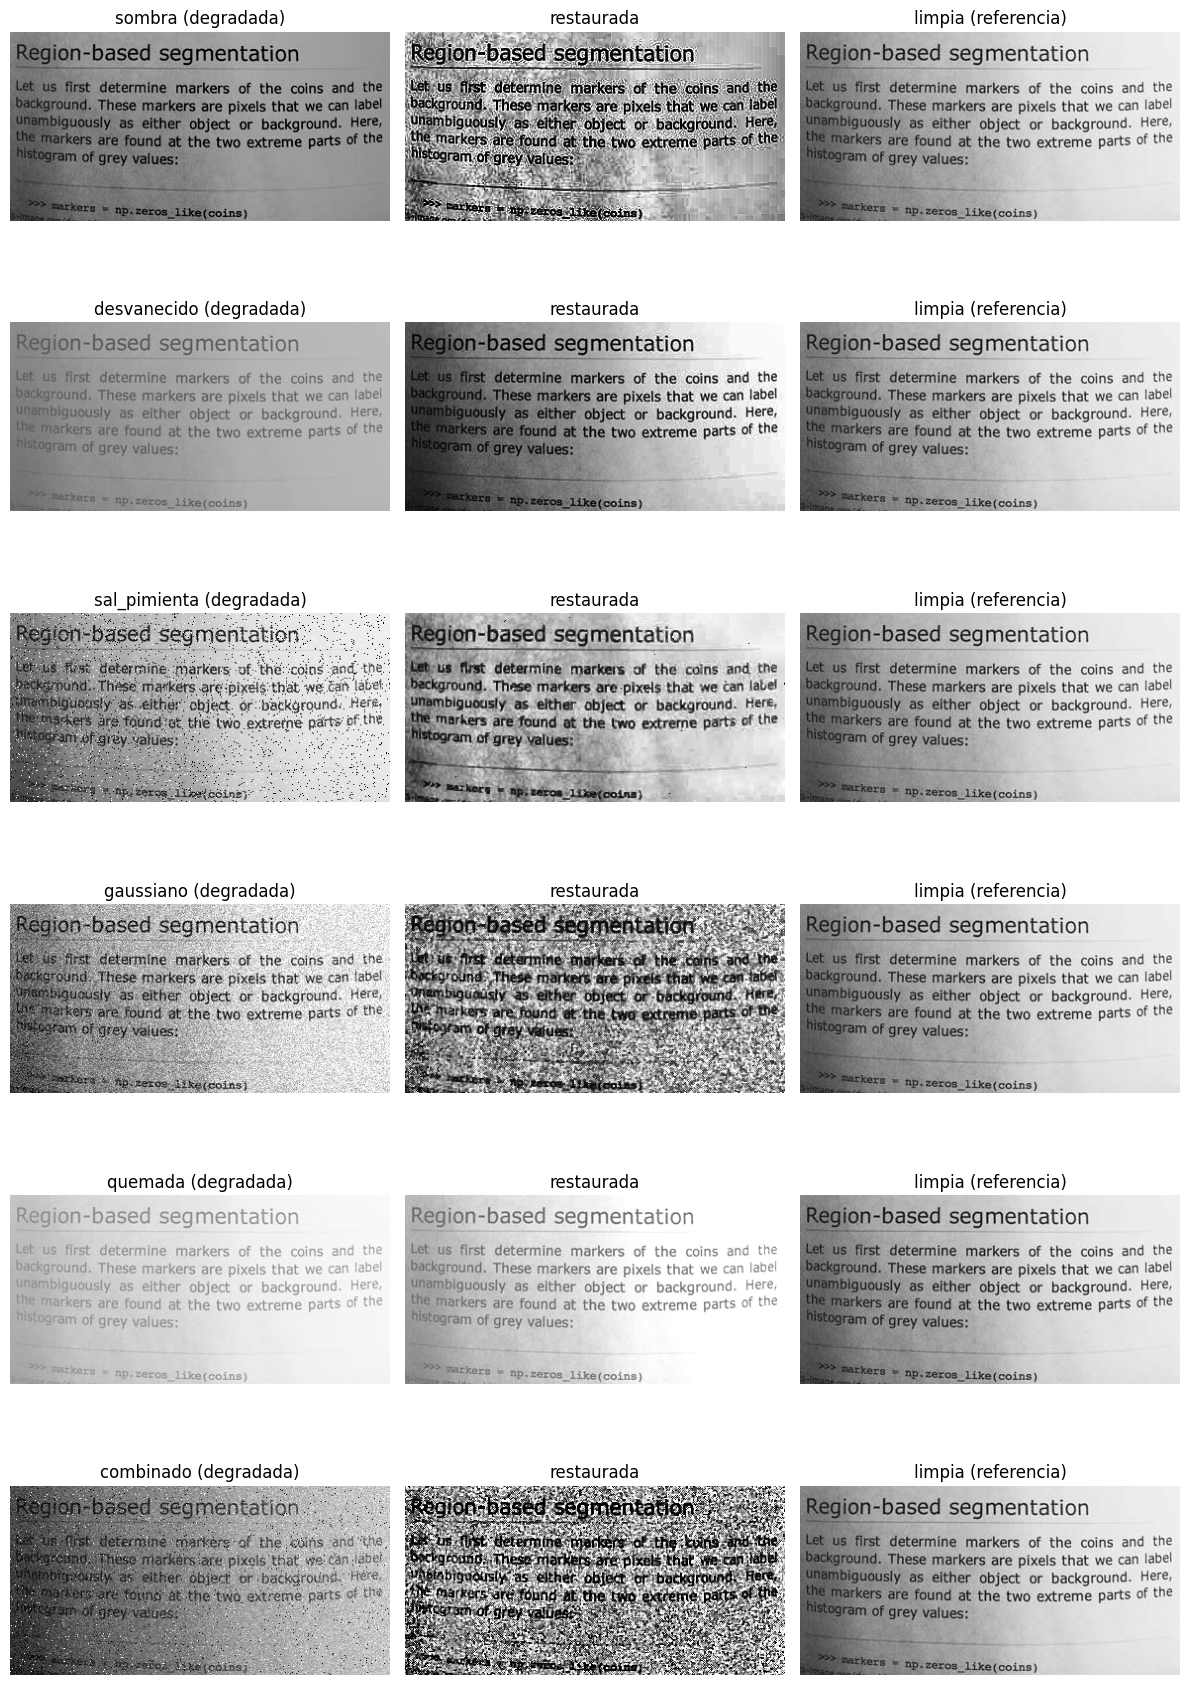

In [ ]:
fig, axes = plt.subplots(len(resultados), 3, figsize=(12, 3*len(resultados)))
for i, (tipo, rest) in enumerate(resultados.items()):
    axes[i,0].imshow(dataset[tipo], cmap='gray', vmin=0, vmax=255)
    axes[i,0].set_title(f'{tipo} (degradada)'); axes[i,0].axis('off')
    axes[i,1].imshow(rest, cmap='gray', vmin=0, vmax=255)
    axes[i,1].set_title('restaurada'); axes[i,1].axis('off')
    axes[i,2].imshow(limpia, cmap='gray', vmin=0, vmax=255)
    axes[i,2].set_title('limpia (referencia)'); axes[i,2].axis('off')
plt.tight_layout(); plt.show()

## 5.4  Discusión del orden de aplicación

**Pregunta 5.4 (importante).** Para el perfil `'completo'`, prueba dos órdenes distintos de las etapas en la imagen `combinado` y reporta cuál es mejor. Por ejemplo:

- Orden A: ruido, contraste, afilado.
- Orden B: contraste, ruido, afilado.

¿Cuál funciona mejor y por qué? Justifica con teoría, no solo con números.

Orden         PSNR (dB)       SSIM
-----------------------------------
Orden A           11.72     0.2812
Orden B           11.33     0.3542


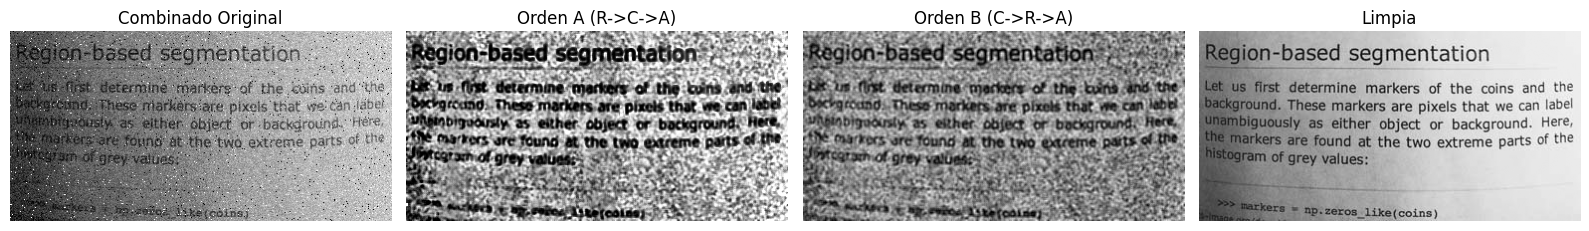

In [ ]:
# Definimos dos funciones para probar los órdenes
def restaurar_orden_A(img):
    # 1. Eliminación de ruido (mediana para sal y pimienta, luego media para gaussiano)
    denoised_img = median(img, disk(1))
    denoised_img = filtro_media(denoised_img, k=3)
    # 2. Corrección de contraste/iluminación (CLAHE)
    corrected_illum = (equalize_adapthist(denoised_img, clip_limit=0.03) * 255).astype(np.uint8)
    # 3. Afilado (Unsharp masking)
    sharpened_img = unsharp(corrected_illum, sigma=1, k=1.0)
    return sharpened_img

def restaurar_orden_B(img):
    # 1. Corrección de contraste/iluminación (CLAHE)
    corrected_illum = (equalize_adapthist(img, clip_limit=0.03) * 255).astype(np.uint8)
    # 2. Eliminación de ruido (mediana para sal y pimienta, luego media para gaussiano)
    denoised_img = median(corrected_illum, disk(1))
    denoised_img = filtro_media(denoised_img, k=3)
    # 3. Afilado (Unsharp masking)
    sharpened_img = unsharp(denoised_img, sigma=1, k=1.0)
    return sharpened_img

img_comb = dataset['combinado']

# Restaurar con Orden A
rest_A = restaurar_orden_A(img_comb)
p_A, s_A = metricas(limpia, rest_A)

# Restaurar con Orden B
rest_B = restaurar_orden_B(img_comb)
p_B, s_B = metricas(limpia, rest_B)

print(f"{'Orden':<10} {'PSNR (dB)':>12} {'SSIM':>10}")
print('-' * 35)
print(f'{"Orden A":<10} {p_A:>12.2f} {s_A:>10.4f}')
print(f'{"Orden B":<10} {p_B:>12.2f} {s_B:>10.4f}')

comparar(
    [img_comb, rest_A, rest_B, limpia],
    ['Combinado Original', 'Orden A (R->C->A)', 'Orden B (C->R->A)', 'Limpia']
)

**RESPUESTA**

El Orden B (contraste → ruido → afilado) es mejor. Ya que aplicar CLAHE primero normaliza la iluminación antes de filtrar, lo que permite al filtro de mediana distinguir mejor entre ruido verdadero y variaciones legítimas de tono. Si se filtra el ruido primero sobre una imagen con iluminación desigual, el filtro puede confundir sombras con ruido y eliminar detalle real. El afilado siempre va al final para no amplificar ruido residual.

---

# Cierre — Reflexión final

Esta sección no tiene código. Solo respuestas razonadas. Vale 25% de la nota (la parte de calidad de respuestas).

**Pregunta 6.1 (síntesis).** En una sola frase, ¿qué aprendiste de este caso que no aprenderías solo leyendo el libro o haciendo el lab del notebook de clase?

Aprendí que elegir y ajustar correctamente las técnicas según el tipo de degradación es tan importante como aplicarlas, y que solo experimentando se entiende cómo pequeñas decisiones en el pipeline pueden mejorar o empeorar significativamente el resultado final.

**Pregunta 6.2 (transferencia).** Imagina que tu siguiente proyecto fuera detectar arrugas en cartas viejas (no restaurar, sino marcar dónde están las arrugas). ¿Qué técnicas de las que viste hoy reusarías y cuál sería el primer paso de tu pipeline? Argumenta brevemente.

Reusaría CLAHE como primer paso para normalizar la iluminación desigual de las cartas viejas, ya que las arrugas solo son visibles si el contraste local está bien definido. Luego aplicaría un filtro de bordes como Sobel o Laplaciano para marcar las zonas de cambio brusco de intensidad, que es donde físicamente aparecen las arrugas.

**Pregunta 6.3 (límites).** ¿Qué tipo de degradación ves que tu pipeline NO logra resolver bien? Sé honesto. ¿Qué necesitarías para resolverlo? Puede ser una técnica que aún no vimos, está bien si miras adelante en el libro.

Mi pipeline actual no resuelve bien degradaciones geométricas (distorsiones, pliegues) o la eliminación de elementos no deseados como sellos o manchas complejas. Necesitaría técnicas de registro de imágenes, segmentación avanzada (con IA, por ejemplo) y quizás inpainting o técnicas de restauración basadas en modelos de textura para abordarlas.

**Pregunta 6.4 (conexión con clases pasadas).** Lista al menos 3 conceptos específicos de los Caps. 1 y 2 que terminaron siendo útiles aquí. Sé concreto: no "matrices" en general, sino por ejemplo "álgebra elemento a elemento para restar imágenes".

- Tipos de datos (dtype) y rangos dinámicos: Es importante manejar correctamente uint8 y float32 para evitar errores como desbordamientos o pérdidas de información al hacer operaciones sobre la imagen.
- Aritmética elemento a elemento: Nos permite aplicar transformaciones como gamma o filtros de forma directa y eficiente, sin necesidad de usar bucles.
- Indexación y vecindades: Sirve para acceder a zonas específicas de la imagen y analizar pequeños parches o píxeles particulares, lo cual es clave para detectar y tratar ruido.